# Task 4

### Importing libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as functional
from torch.distributions import Normal, kl_divergence
from torch.utils.data import DataLoader
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt 

if torch.cuda.is_available() == True:
    device = 'cuda'
else:
    device = 'cpu'

print(f'device: {device}')



device: cpu


# Task 4.1

### Loading dataset

In [2]:
mnist_train = datasets.MNIST(root='../data', train=True, transform=transforms.ToTensor(), download=True)
mnist_test = datasets.MNIST(root='../data', train=False, transform=transforms.ToTensor(), download=True)

train_dataloader = DataLoader(mnist_train, batch_size=64, shuffle=True)
test_dataloader = DataLoader(mnist_test, batch_size=64, shuffle=False)



Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:54<00:00, 182kB/s] 


Extracting ../data/MNIST/raw/train-images-idx3-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 101kB/s]


Extracting ../data/MNIST/raw/train-labels-idx1-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:54<00:00, 30.4kB/s]


Extracting ../data/MNIST/raw/t10k-images-idx3-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 4.09MB/s]

Extracting ../data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ../data/MNIST/raw



### Implementing VAE from scratch

In [3]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

        self.mean_layer = nn.Linear(128, 32)
        self.logvar_layer = nn.Linear(128, 32)

        self.normal_distribution = Normal(0, 1)

        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x_encoded = self.encoder(x)

        x_mean = self.mean_layer(x_encoded)
        x_logvar = self.logvar_layer(x_encoded)

        x_dev = torch.exp(0.5 * x_logvar)
        normal_sampled = self.normal_distribution.sample((x_mean.shape[0], x_mean.shape[1]))

        z = x_mean + x_dev * normal_sampled

        x_decoded = self.decoder(z)

        return x_decoded, x_mean, x_logvar

    def compute_loss(self, x, x_mean, x_logvar, output):
        distribution_1 = Normal(x_mean, torch.exp(0.5 * x_logvar))
        distribution_2 = self.normal_distribution

        loss = kl_divergence(distribution_1, distribution_2).sum(dim=1) + functional.binary_cross_entropy(output, x, reduction='none').sum(dim=1)

        return loss.sum(dim=0)/loss.shape[0]




### Training the VAE

In [5]:
vae = VAE()
EPOCHS = 15
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

loss_over_epochs = []

for i in range(EPOCHS):
    print(f'epoch: {i}')
    curr_loss = 0

    vae.train()
    
    for image, label in train_dataloader:
        optimizer.zero_grad()

        image = torch.flatten(image, start_dim=1)

        output, image_mean, image_logvar = vae(image)

        loss = vae.compute_loss(image, image_mean, image_logvar, output)
        curr_loss += loss.item()

        loss.backward()

        optimizer.step()

    curr_loss = curr_loss / len(train_dataloader)
    loss_over_epochs.append(curr_loss)
    print(f'loss: {curr_loss} \n')



epoch: 0
loss: 172.4615559201759 

epoch: 1
loss: 134.35355435759783 

epoch: 2
loss: 127.53967029758608 

epoch: 3
loss: 122.78448542450536 

epoch: 4
loss: 118.65847936113761 

epoch: 5
loss: 116.28950833969279 

epoch: 6
loss: 114.83642190148328 

epoch: 7
loss: 113.767984410593 

epoch: 8
loss: 112.84098462102764 

epoch: 9
loss: 112.21054393548701 

epoch: 10
loss: 111.58801188194421 

epoch: 11
loss: 111.06894469108663 

epoch: 12
loss: 110.58402092777081 

epoch: 13
loss: 110.28643580032056 

epoch: 14
loss: 109.87468928518072 



### Visualizing loss

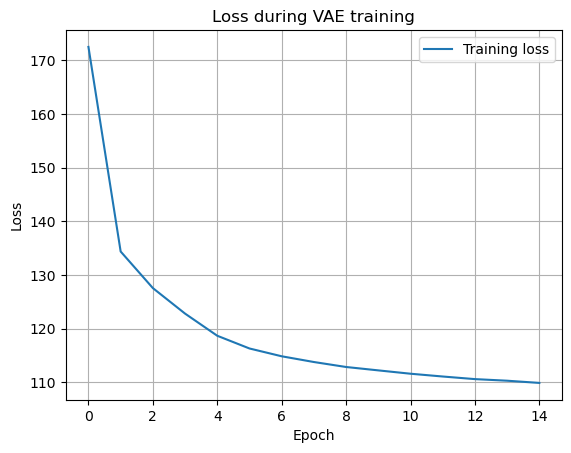

In [6]:
plt.figure()
plt.plot(loss_over_epochs, label='Training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss during VAE training')
plt.grid()
plt.legend()

plt.show()